In [1]:
#import the required libraries

import pandas as pd #for data manipulation and analysis
import numpy as np #for mathematical and numerical computing
import matplotlib.pyplot as plt #for data visualization (low-level)
import seaborn as sns #for data visualization (high-level)
import warnings # to issue non-fatal alerts to developers and users
warnings.filterwarnings('ignore') #tells the code to completely suppress all warning messages
%matplotlib inline
sns.set(color_codes=True)


In [2]:
jobs = pd.read_csv('jobs.csv')

In [3]:
jobs.dtypes

,0
job_title,object
category,object
job_category,object
location,object
employment_type,object
vacancy,int64
company,object
company_site,object
industry,object
office_address,object


In [4]:
# to check the size of dataset
jobs.shape

(1043, 10)

In [5]:
# to check how many duplicates
duplicate_rows = jobs[jobs.duplicated()]
print("duplicate rows: ", duplicate_rows.shape)

duplicate rows:  (112, 10)


In [6]:
# to remove duplicates
jobs = jobs.drop_duplicates()

In [7]:
duplicate_rows = jobs[jobs.duplicated()]
print("duplicate rows: ", duplicate_rows.shape)

duplicate rows:  (0, 10)


In [8]:
# to print the count of missing value for each column
print(jobs.isnull().sum())

job_title           1
category            0
job_category        0
location            0
employment_type     0
vacancy             0
company             0
company_site       25
industry            0
office_address      0
dtype: int64


In [9]:
# to remove rows with null values
jobs = jobs.dropna()

In [10]:
print(jobs.isnull().sum())

job_title          0
category           0
job_category       0
location           0
employment_type    0
vacancy            0
company            0
company_site       0
industry           0
office_address     0
dtype: int64


In [11]:
jobs.count()

,0
job_title,905
category,905
job_category,905
location,905
employment_type,905
vacancy,905
company,905
company_site,905
industry,905
office_address,905


In [12]:
# finding the interquartile range
jobs_numeric = jobs.select_dtypes(include=[np.number])

q1 = jobs_numeric.quantile(.25)
q3 = jobs_numeric.quantile(.75)
iqr = q3 - q1

print(iqr)

vacancy    1.0
dtype: float64


In [13]:
# removing the outliers from numerical columns only
jobs_no_outliers = jobs_numeric[~((jobs_numeric < (q1 - 1.5 * iqr)) | (jobs_numeric > (q3 + 1.5 * iqr))).any(axis=1)]

# merge the filtered numerical data with the non-numerical columns from the original DataFrame
jobs = pd.merge(jobs_no_outliers, jobs.select_dtypes(exclude=[np.number]), left_index=True, right_index=True)

# reset the index of the merged DataFrame
# jobs.reset_index(drop=True, inplace=True

jobs.shape

(766, 10)

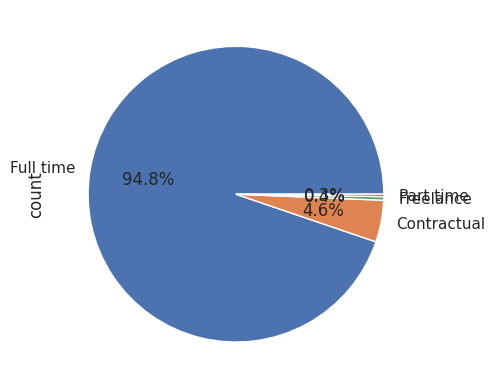

In [14]:
jobs["employment_type"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.show()

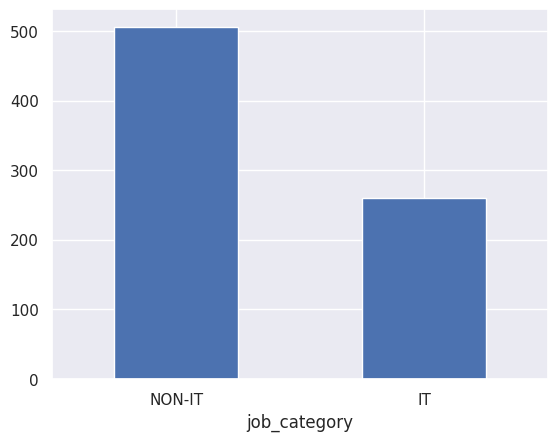

In [15]:
jobs["job_category"].value_counts().head(10).plot(kind="bar")
plt.xticks(rotation=0)
plt.show()

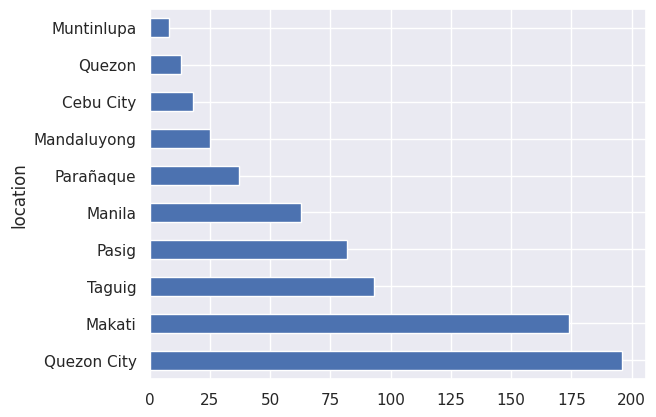

In [16]:
jobs["location"].value_counts().head(10).plot(kind="barh")
plt.show()

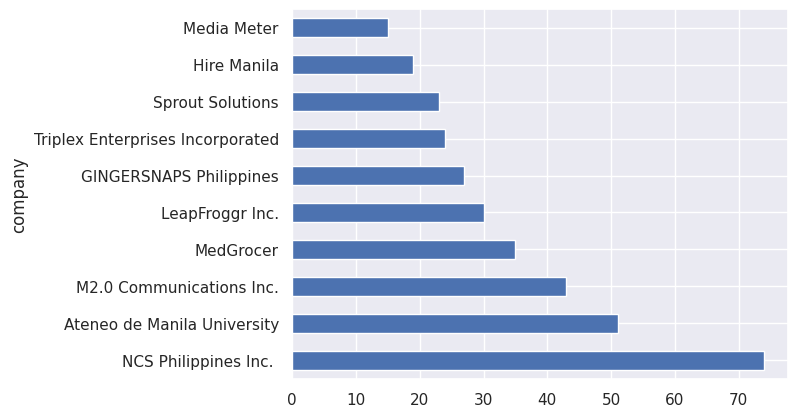

In [17]:
jobs["company"].value_counts().head(10).plot(kind="barh")
plt.show()

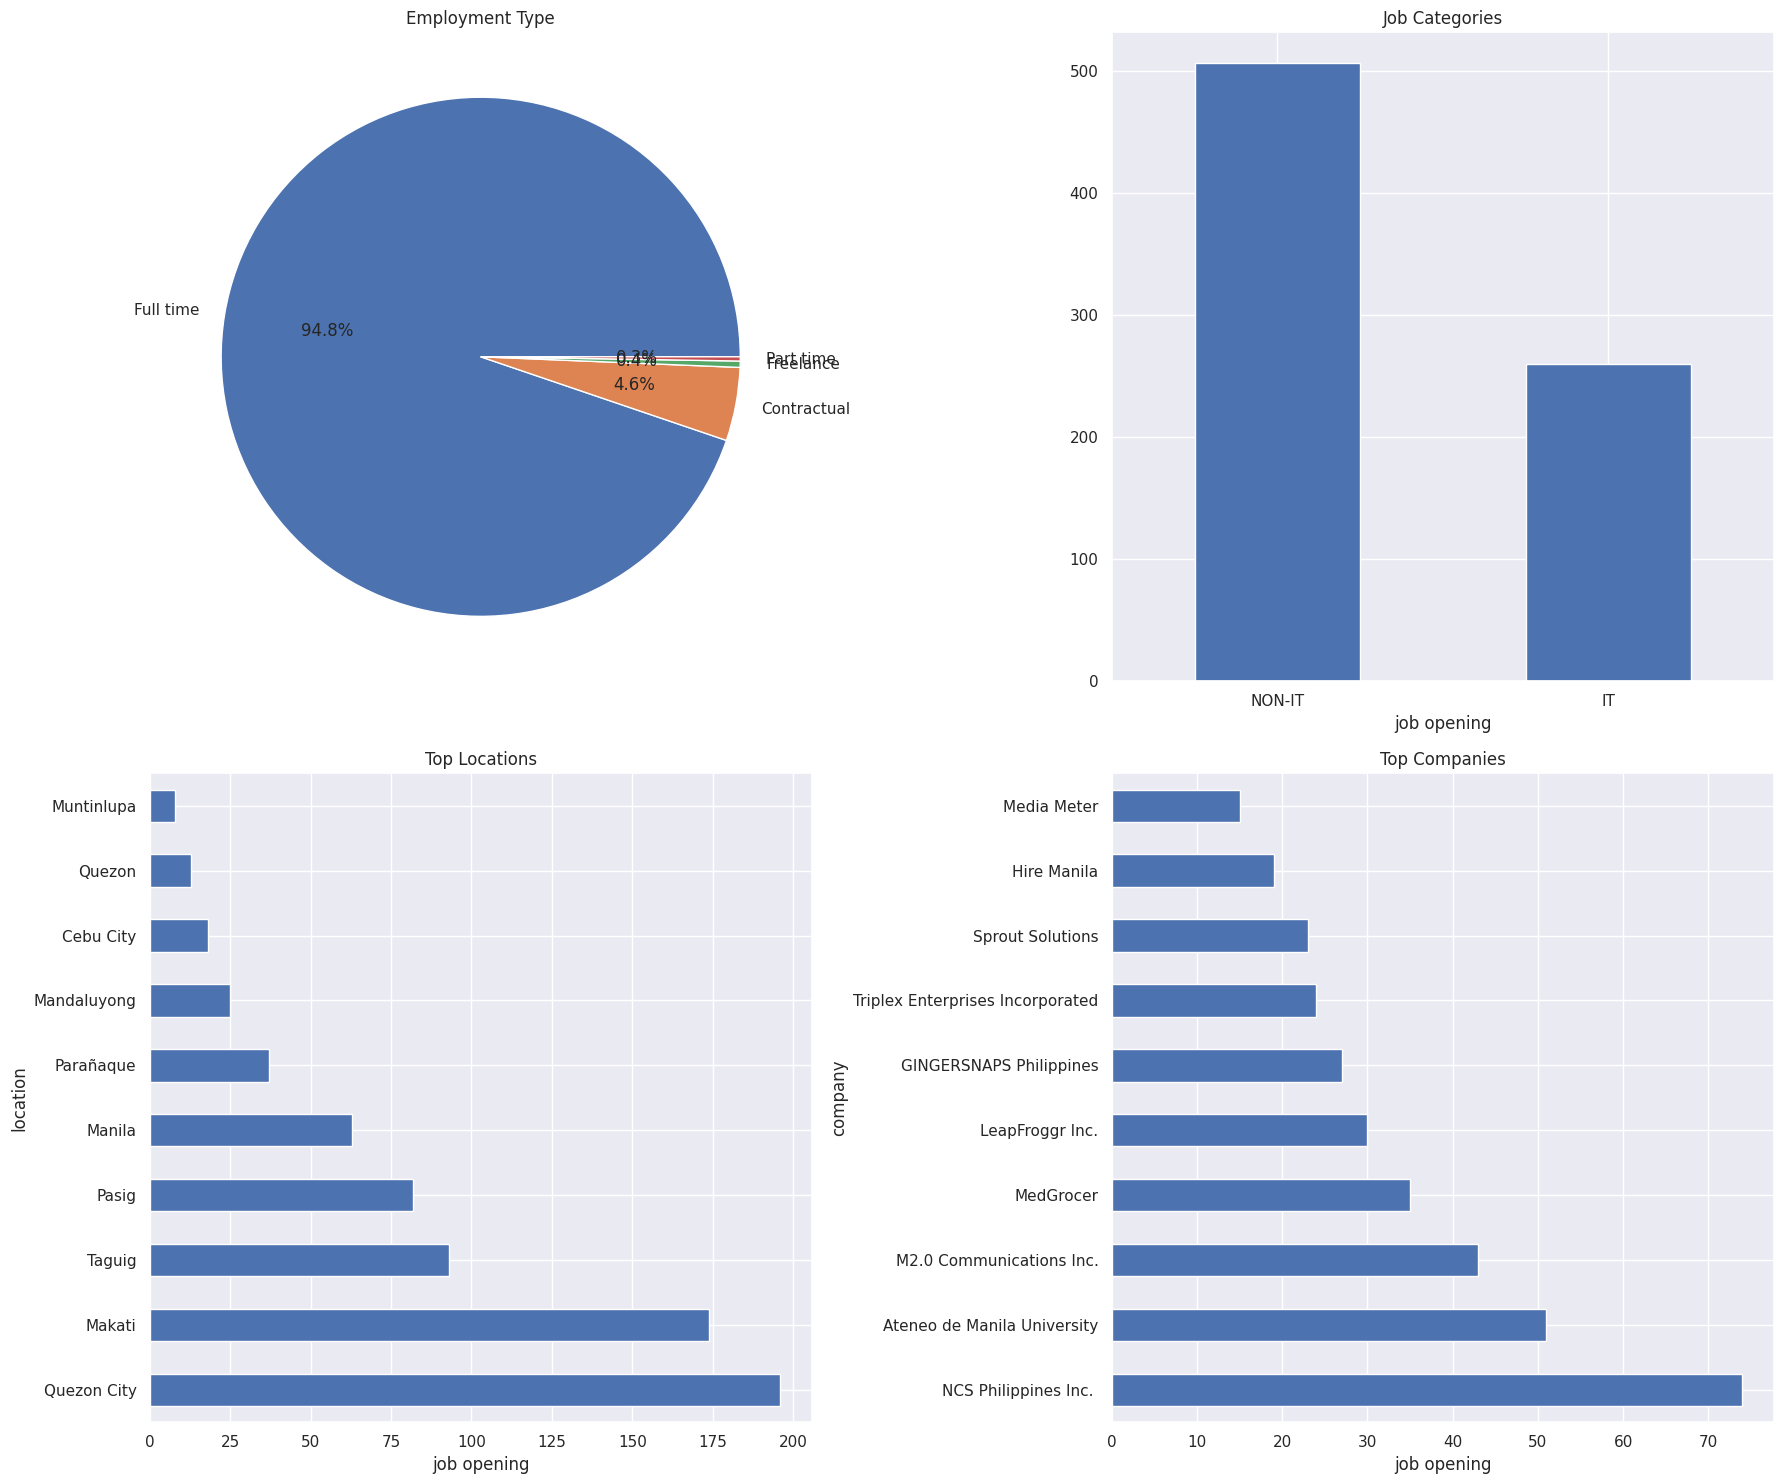

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(18, 15))

# employment type count
jobs["employment_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=axes[0,0]
)
axes[0,0].set_title("Employment Type")
axes[0,0].set_ylabel("")


# job category count
jobs["job_category"].value_counts().head(10).plot(
    kind="bar",
    ax=axes[0,1],
    rot = 0
)
axes[0,1].set_title("Job Categories")
axes[0,1].set_xlabel("job opening")



# top 10 location with job opening
jobs["location"].value_counts().head(10).plot(
    kind="barh",
    ax=axes[1,0]
)
axes[1,0].set_title("Top Locations")
axes[1,0].set_xlabel("job opening")


# top 10 company with job opening
jobs["company"].value_counts().head(10).plot(
    kind="barh",
    ax=axes[1,1]
)
axes[1,1].set_title("Top Companies")
axes[1,1].set_xlabel("job opening")

plt.tight_layout()
plt.show()